# 09 — Job Seeker Guide

Synthesis notebook combining insights from earlier analyses into 4 actionable job seeker personas. Translates the analytical findings into concrete guidance on skills to prioritise, cities to target, and salary expectations for each persona type.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import (
    exclude_future_dates, exclude_other_family,
    filter_by_seniority, filter_remote, salary_df, explode_json_col,
)

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 18,949 rows × 25 columns
After excluding future-dated rows: 18,899 rows


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, value_bar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Quality Overview

In [3]:
sdf_all = salary_df(df)
print(f"Total postings: {len(df):,}")
print(f"Postings with salary data: {len(sdf_all):,} ({len(sdf_all)/len(df)*100:.1f}%)")
print(f"Postings with city: {df['city'].notna().sum():,} ({df['city'].notna().mean()*100:.1f}%)")
print(f"Postings with seniority: {df['seniority_from_title'].notna().sum():,} ({df['seniority_from_title'].notna().mean()*100:.1f}%)")

Total postings: 18,899
Postings with salary data: 403 (2.1%)
Postings with city: 17,753 (93.9%)
Postings with seniority: 5,849 (30.9%)


## The 4 Personas

| Persona | Definition | Filter criteria |
|---------|-----------|----------------|
| **Junior** | Entry-level candidates | `seniority_from_title == "Junior"` |
| **Senior** | Experienced professionals | `seniority_from_title in ["Senior", "Lead"]` |
| **Remote-First** | Location-independent workers | `work_modality == "Remote"` |
| **Career-Changer** | Transitioning into IT | `job_family == "Other"` |

> **Note on Career-Changer persona:** Using `job_family == "Other"` as a proxy for career-changer roles is imperfect. The "Other" category is a catch-all for postings that did not map to a recognised IT job family. While some of these may genuinely be entry points for career changers, many are simply niche or ambiguous roles. Interpret this persona's results with caution.

In [4]:
personas = {
    "Junior": filter_by_seniority(df, "Junior"),
    "Senior": df[df["seniority_from_title"].isin(["Senior", "Lead"])],
    "Remote-First": filter_remote(df),
    "Career-Changer": df[df["job_family"].str.lower() == "other"],
}

summary_rows = []
for name, pdf in personas.items():
    sdf = salary_df(pdf)
    summary_rows.append({
        "Persona": name,
        "Total postings": f"{len(pdf):,}",
        "% of market": f"{len(pdf)/len(df)*100:.1f}%",
        "Salary known": f"{len(sdf):,}",
        "Top job family": pdf["job_family"].value_counts().index[0] if len(pdf) else "N/A",
        "Median salary (€)": f"€{int(sdf['salary_mid'].median()):,}" if len(sdf) else "N/A",
        "Remote %": f"{(pdf['work_modality'].str.lower() == 'remote').mean()*100:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Persona")
summary_df

,Total postings,% of market,Salary known,Top job family,Median salary (€),Remote %
Persona,,,,,,
Junior,736,3.9%,10,Intern,"€47,500",30.6%
Senior,"5,046",26.7%,120,SAP Consultant,"€77,500",26.5%
Remote-First,"4,604",24.4%,149,Fullstack Developer,"€70,000",100.0%
Career-Changer,885,4.7%,8,Other,"€60,125",29.5%


**Takeaway:** The four personas capture distinct segments of the German IT job market. Junior roles form a modest share, reflecting a market that skews towards experienced hires. The Remote-First segment is growing but still a minority. Note the very small salary-known counts — salary estimates for individual personas should be treated as indicative rather than definitive.

## Skills Roadmap by Persona

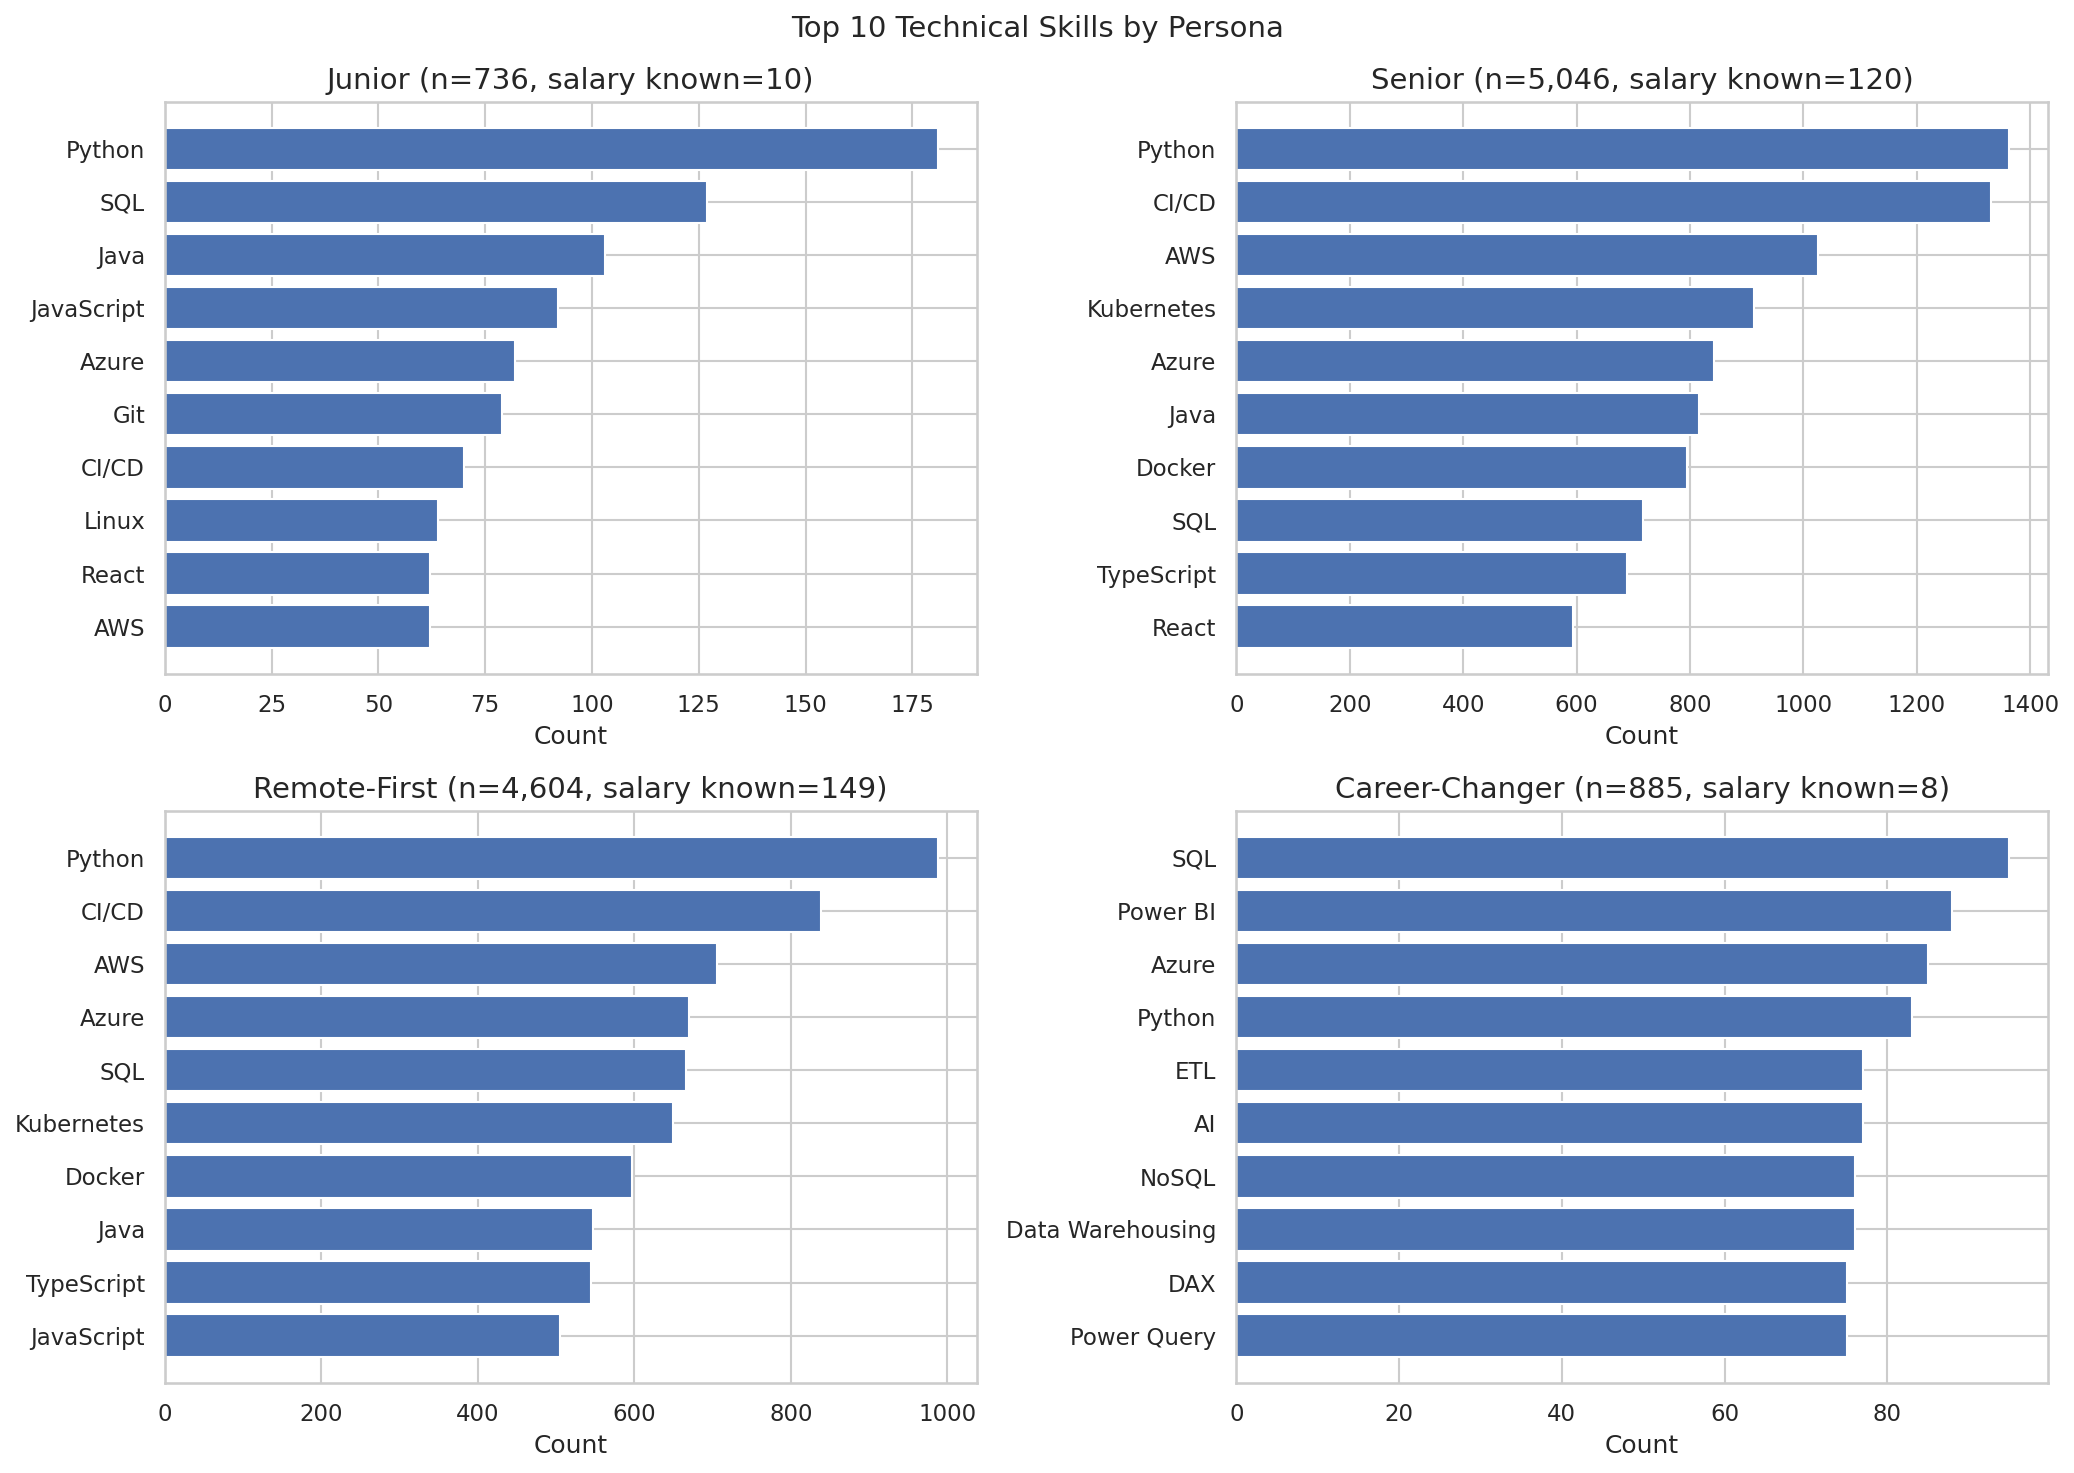

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 10 Technical Skills by Persona", fontsize=14)

for ax, (name, pdf) in zip(axes.flat, personas.items()):
    if len(pdf) == 0:
        ax.set_title(name)
        continue
    top_skills = (
        explode_json_col(pdf, "technical_skills")["technical_skills"]
        .value_counts()
        .head(10)
        .sort_values()
    )
    sdf = salary_df(pdf)
    ax.barh(top_skills.index, top_skills.values)
    ax.set_title(f"{name} (n={len(pdf):,}, salary known={len(sdf):,})")
    ax.set_xlabel("Count")

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "09_skills_by_persona.png", dpi=150)
plt.show()
plt.close(fig)

**Takeaway:** Python, SQL, and JavaScript appear across all personas, confirming their status as foundational IT skills. Junior roles emphasise breadth (web frameworks, general languages), while Senior roles lean towards architecture and infrastructure tools. Remote-First roles favour cloud-native technologies. Career-Changer roles show a less defined skill profile, consistent with the catch-all nature of the "Other" family.

## Best Cities per Persona

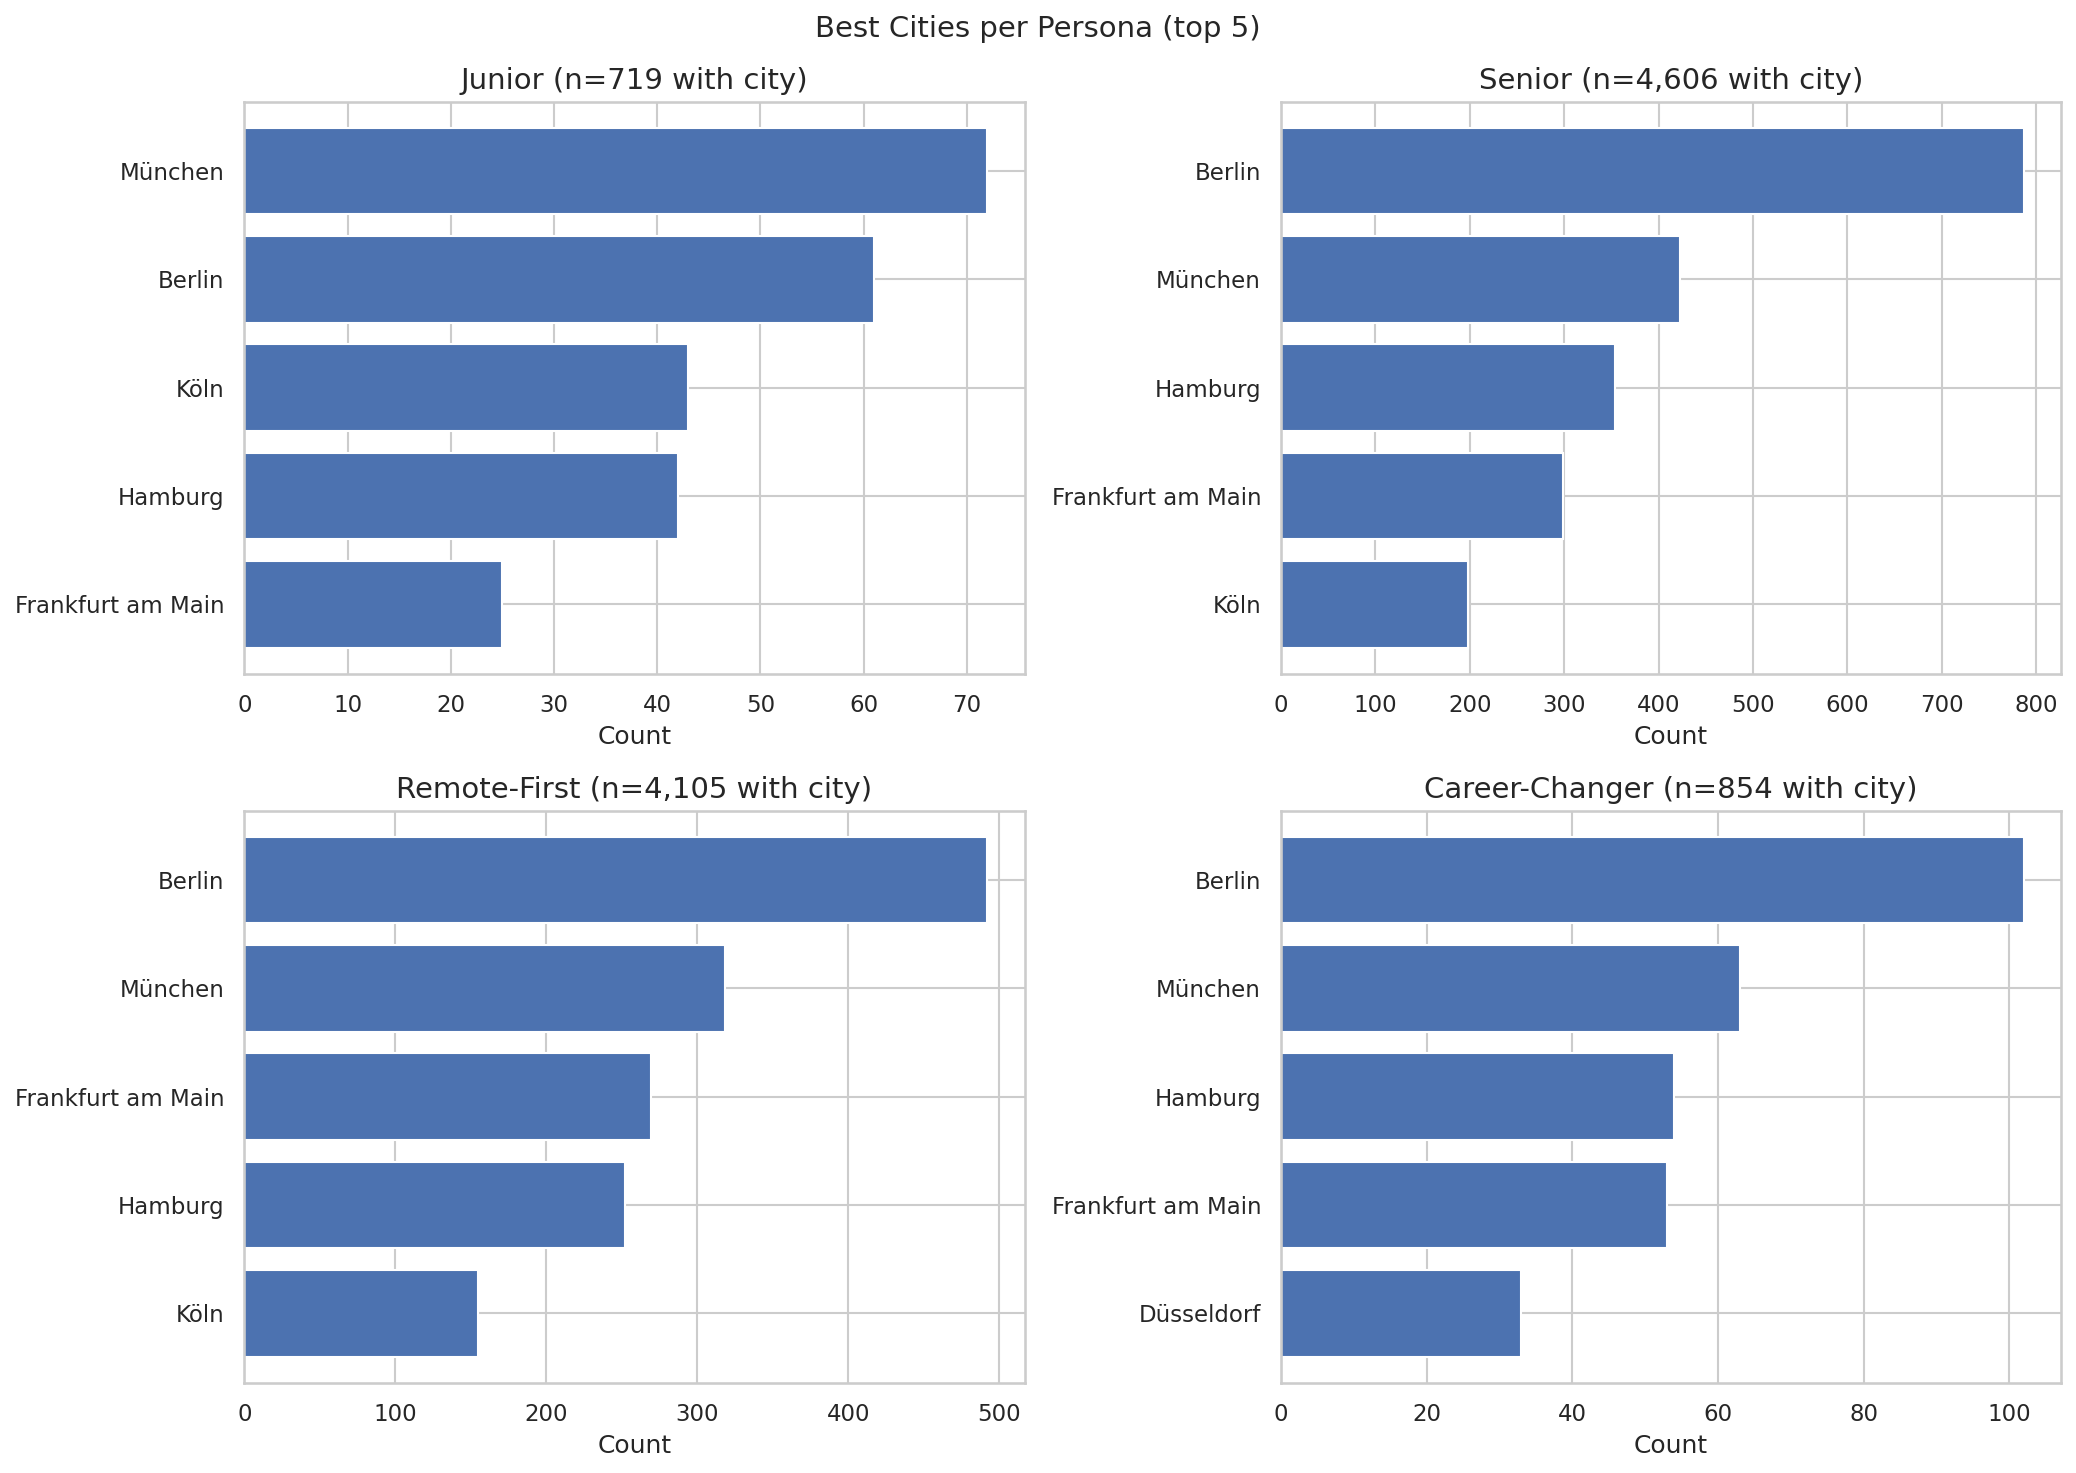

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Best Cities per Persona (top 5)", fontsize=14)

for ax, (name, pdf) in zip(axes.flat, personas.items()):
    city_df = pdf[pdf["city"].notna()]
    if len(city_df) == 0:
        ax.set_title(name)
        continue
    top_cities = city_df["city"].value_counts().head(5).sort_values()
    ax.barh(top_cities.index, top_cities.values)
    ax.set_title(f"{name} (n={len(city_df):,} with city)")
    ax.set_xlabel("Count")

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "09_cities_by_persona.png", dpi=150)
plt.show()
plt.close(fig)

**Takeaway:** Berlin, München, and Hamburg dominate across all personas, which is consistent with these cities being Germany's major tech hubs. For Remote-First seekers, the city distribution still matters for hybrid options and networking, but the concentration is less pronounced. Frankfurt appears more prominently for Senior roles, reflecting its financial-sector IT demand.

## Salary Expectations

In [7]:
salary_rows = []
for name, pdf in personas.items():
    sdf = salary_df(pdf)
    if len(sdf) == 0:
        salary_rows.append({
            "Persona": name,
            "Count (salary known)": 0,
            "Median": "N/A", "P25": "N/A", "P75": "N/A"
        })
        continue
    salary_rows.append({
        "Persona": name,
        "Count (salary known)": len(sdf),
        "Median": f"€{int(sdf['salary_mid'].median()):,}",
        "P25": f"€{int(sdf['salary_mid'].quantile(0.25)):,}",
        "P75": f"€{int(sdf['salary_mid'].quantile(0.75)):,}",
    })

salary_table = pd.DataFrame(salary_rows).set_index("Persona")
salary_table

,Count (salary known),Median,P25,P75
Persona,,,,
Junior,10,"€47,500","€42,375","€56,875"
Senior,120,"€77,500","€67,500","€95,625"
Remote-First,149,"€70,000","€57,500","€90,000"
Career-Changer,8,"€60,125","€54,275","€93,750"


**Takeaway:** Salary data is sparse (only ~2% of postings include salary), so these figures are indicative ranges rather than precise benchmarks. The Senior persona commands the highest median, as expected. Remote-First roles show competitive salaries, suggesting that remote work does not come with a significant pay penalty in the German IT market.

## Top Cities by Job Family

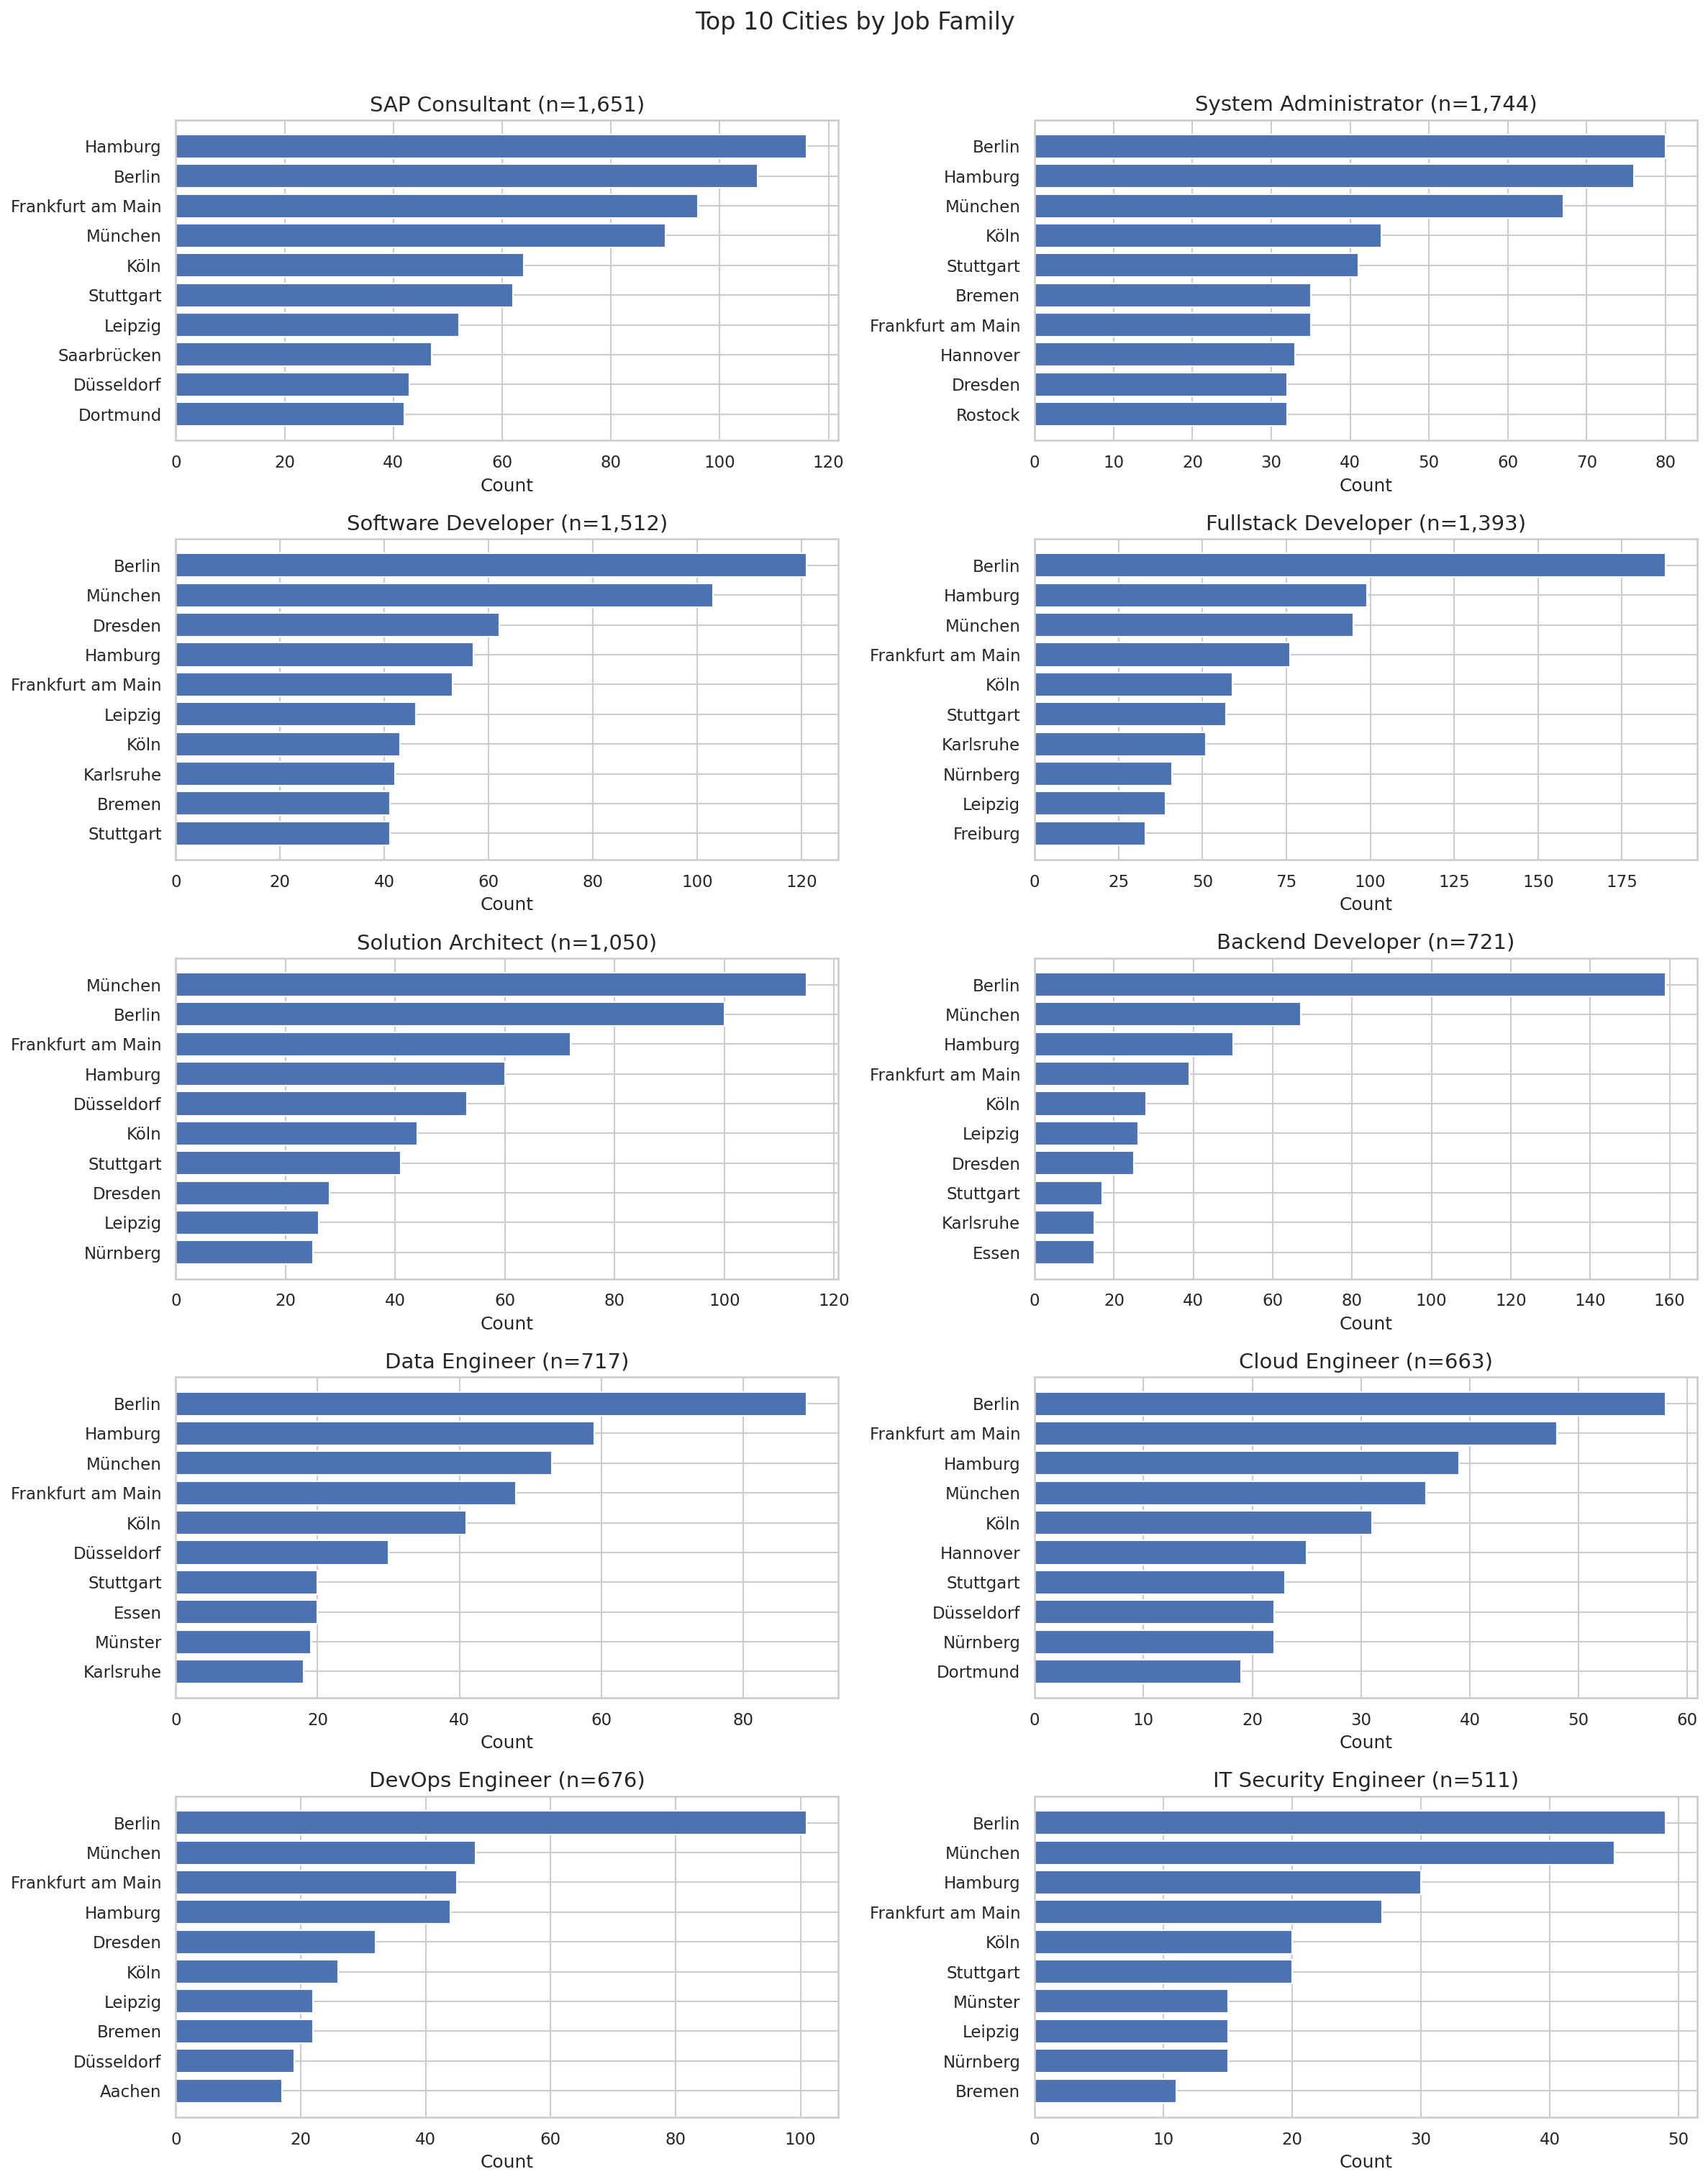

In [8]:
df_fam = exclude_other_family(df)
top_families = df_fam["job_family"].value_counts().head(10).index
city_df = df_fam[df_fam["city"].notna()]

rows_count = int(np.ceil(len(top_families) / 2))
fig, axes = plt.subplots(rows_count, 2, figsize=(16, 4 * rows_count))
fig.suptitle("Top 10 Cities by Job Family", fontsize=16, y=1.01)

for ax, family in zip(axes.flat, top_families):
    fam_city = city_df[city_df["job_family"] == family]
    family_cities = fam_city["city"].value_counts().head(10).sort_values()
    ax.barh(family_cities.index, family_cities.values)
    ax.set_title(f"{family} (n={len(fam_city):,})")
    ax.set_xlabel("Count")

# Hide unused axes
for ax in axes.flat[len(top_families):]:
    ax.set_visible(False)

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "09_cities_by_family.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

**Takeaway:** While Berlin leads almost universally, certain families show geographic concentration. Financial IT clusters in Frankfurt, automotive-related roles appear more in München and Stuttgart, and Hamburg has a strong showing in e-commerce-related development roles. Job seekers should consider family-specific city strengths when choosing where to focus their search.

## Median Salary by Job Family

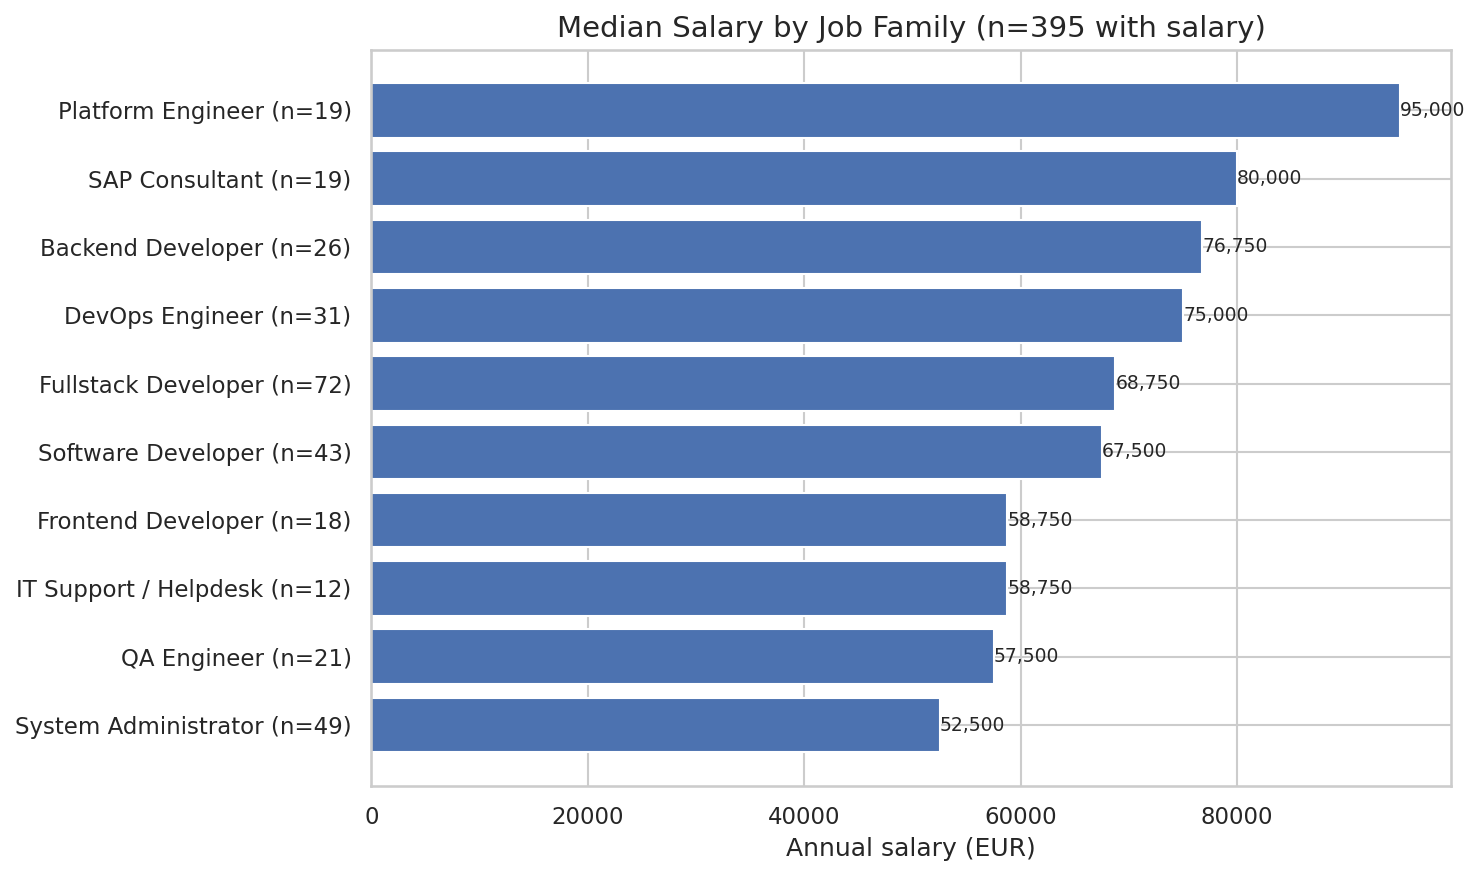

In [9]:
sdf_all = salary_df(df)
sdf_fam = exclude_other_family(sdf_all)
top_families_salary = sdf_fam["job_family"].value_counts().head(10).index

family_grp = sdf_fam[sdf_fam["job_family"].isin(top_families_salary)].groupby("job_family")
family_median = family_grp["salary_mid"].median().sort_values()
family_n = family_grp.size()

labels = [f"{fam} (n={family_n[fam]:,})" for fam in family_median.index]

value_bar(
    labels,
    family_median.values,
    f"Median Salary by Job Family (n={len(sdf_fam):,} with salary)",
    xlabel="Annual salary (EUR)",
    fmt=",.0f",
    save_as="09_salary_by_family.png",
)

**Takeaway:** Salary differences between job families are visible but should be interpreted cautiously given the small sample sizes. Higher-paying families tend to be those requiring more specialised skills or more senior-heavy role distributions. The salary advantage of certain families may partly reflect seniority composition rather than inherently higher pay for the role type.